### Exercise 8

Practice training a deep neural network on the CIFAR10 image dataset:

a. Load CIFAR10 just like you loaded the FashionMNIST dataset in Chapter 10, but using torchvision.datasets.CIFAR10 instead of FashionMNIST. The dataset is composed of 60,000 32 × 32–pixel color images (50,000 for training, 10,000 for testing) with 10 classes.

In [1]:
# Get the dataset with torchvision
import torch
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=toTensor
)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor
)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [45_000, 5_000]
)

In [2]:
# Check that datasets are balanced with regard to labels
import numpy as np

print(np.unique_counts([t[1] for t in train_data]))
print(np.unique_counts([v[1] for v in valid_data]))
print(np.unique_counts([t[1] for t in test_data]))

UniqueCountsResult(values=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), counts=array([4512, 4488, 4468, 4529, 4529, 4486, 4493, 4500, 4496, 4499]))
UniqueCountsResult(values=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), counts=array([488, 512, 532, 471, 471, 514, 507, 500, 504, 501]))
UniqueCountsResult(values=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), counts=array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))


In [3]:
from torch.utils.data import DataLoader

batch_size = 512
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

b. Build a DNN with 20 hidden layers of 100 neurons each (that’s too many, but it’s the point of this exercise).

Use He initialization and the Swish activation function (using nn.SiLU). 

Since this is a classification task, you will need an output layer with one neuron per class.

In [4]:
import torch.nn as nn

class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_layers, n_hidden, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden),  # Input layer
            nn.SiLU()
        )
        for i in range(n_layers):  # Hidden layers
            self.mlp.append(nn.Linear(n_hidden, n_hidden))
            self.mlp.append(nn.SiLU())
        self.mlp.append(nn.Linear(n_hidden, n_classes))  # Output layer


    def forward(self, X):
        return self.mlp(X)
    
torch.manual_seed(42)
model = ImageClassifier(n_inputs=3 * 32 * 32, n_layers=20, n_hidden=100, n_classes=10)
model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=100, bias=True)
    (2): SiLU()
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): SiLU()
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): SiLU()
    (7): Linear(in_features=100, out_features=100, bias=True)
    (8): SiLU()
    (9): Linear(in_features=100, out_features=100, bias=True)
    (10): SiLU()
    (11): Linear(in_features=100, out_features=100, bias=True)
    (12): SiLU()
    (13): Linear(in_features=100, out_features=100, bias=True)
    (14): SiLU()
    (15): Linear(in_features=100, out_features=100, bias=True)
    (16): SiLU()
    (17): Linear(in_features=100, out_features=100, bias=True)
    (18): SiLU()
    (19): Linear(in_features=100, out_features=100, bias=True)
    (20): SiLU()
    (21): Linear(in_features=100, out_features=100, bias=True)
    (22): SiLU()
    (23): Linear(in_features=100, out_features=1

In [5]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model.apply(use_he_init)

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=100, bias=True)
    (2): SiLU()
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): SiLU()
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): SiLU()
    (7): Linear(in_features=100, out_features=100, bias=True)
    (8): SiLU()
    (9): Linear(in_features=100, out_features=100, bias=True)
    (10): SiLU()
    (11): Linear(in_features=100, out_features=100, bias=True)
    (12): SiLU()
    (13): Linear(in_features=100, out_features=100, bias=True)
    (14): SiLU()
    (15): Linear(in_features=100, out_features=100, bias=True)
    (16): SiLU()
    (17): Linear(in_features=100, out_features=100, bias=True)
    (18): SiLU()
    (19): Linear(in_features=100, out_features=100, bias=True)
    (20): SiLU()
    (21): Linear(in_features=100, out_features=100, bias=True)
    (22): SiLU()
    (23): Linear(in_features=100, out_features=1

c. Using NAdam optimization and early stopping, train the network on the CIFAR10 dataset. 

Remember to search for the right learning rate each time you change the model’s architecture or hyperparameters.

In [6]:
optimizer = torch.optim.NAdam(model.parameters(), lr=0.002, betas=(0.9, 0.999))    # default values


In [7]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_metric = None
        self.no_improvement_count = 0
        self.stop_training = False
    
    def check_early_stop(self, val_metric):
        if self.best_metric is None or val_metric > self.best_metric + self.delta:
            self.best_metric = val_metric
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [8]:
patience = 5  # epochs to wait after no improvement
delta = 0.01  # minimum change in the monitored metric
#best_val_metric = 0.0  # best validation metric to compare against
no_improvement_count = 0  # count of epochs with no improvement
# Initialize early stopping
early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)

In [9]:
def evaluate_tm(model, data_loader, metric, device=None):
    if device:
        model = model.to(device)
        metric = metric.to(device)
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            if device:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end


def train_with_early_stopping(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs, early_stopping, device=None):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    if device:
        model = model.to(device)
        metric = metric.to(device)
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            if device:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)    # forward pass
            loss = criterion(y_pred, y_batch)    # compute loss for this batch
            total_loss = total_loss +  loss.item()
            loss.backward()    # compute gradients of the loss
            optimizer.step()   # adjust the model weights based on the gradients
            optimizer.zero_grad()    # zero the gradients for next batch
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric, device=device).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        # Check early stopping condition
        early_stopping.check_early_stop(val_metric)
        if early_stopping.stop_training:
            print(f"Early stopping at epoch {epoch}")
            break
    return history

In [10]:
import torchmetrics

device="mps"
n_epochs=30
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train_with_early_stopping(model, optimizer, xentropy, accuracy,
                  train_loader, valid_loader, n_epochs, early_stopping, device=device)

Epoch 1/30, train loss: 2.3490, train metric: 0.1152, valid metric: 0.1014
Epoch 2/30, train loss: 2.2904, train metric: 0.1223, valid metric: 0.1366
Epoch 3/30, train loss: 2.2971, train metric: 0.1203, valid metric: 0.1028
Epoch 4/30, train loss: 2.2976, train metric: 0.1187, valid metric: 0.1002
Epoch 5/30, train loss: 2.2973, train metric: 0.1149, valid metric: 0.0976
Epoch 6/30, train loss: 2.2420, train metric: 0.1322, valid metric: 0.1664
Epoch 7/30, train loss: 2.1016, train metric: 0.1836, valid metric: 0.2134
Epoch 8/30, train loss: 2.0553, train metric: 0.2136, valid metric: 0.2406
Epoch 9/30, train loss: 2.0508, train metric: 0.2307, valid metric: 0.1664
Epoch 10/30, train loss: 1.9740, train metric: 0.2628, valid metric: 0.2816
Epoch 11/30, train loss: 1.9063, train metric: 0.2900, valid metric: 0.3152
Epoch 12/30, train loss: 1.9192, train metric: 0.2909, valid metric: 0.3214
Epoch 13/30, train loss: 1.8492, train metric: 0.3191, valid metric: 0.3222
Epoch 14/30, train lo

<Axes: >

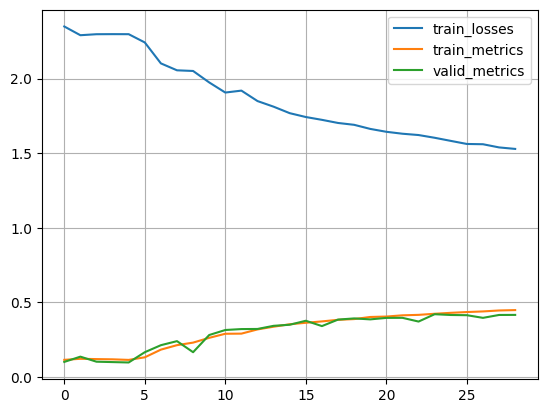

In [11]:
import pandas as pd

history_df = pd.DataFrame(data=history)
history_df.plot(grid=True)

Let's try also reducing the learning rate on plateaus:

In [12]:
def train_with_early_stopping(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs, early_stopping=None, scheduler=None, device=None):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    if device:
        model = model.to(device)
        metric = metric.to(device)
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            if device:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)    # forward pass
            loss = criterion(y_pred, y_batch)    # compute loss for this batch
            total_loss = total_loss +  loss.item()
            loss.backward()    # compute gradients of the loss
            optimizer.step()   # adjust the model weights based on the gradients
            optimizer.zero_grad()    # zero the gradients for next batch
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric, device=device).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        # Check early stopping condition
        if early_stopping:
            early_stopping.check_early_stop(val_metric)
            if early_stopping.stop_training:
                print(f"Early stopping at epoch {epoch}")
                break
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metric)
            else:
                scheduler.step()
            print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

In [13]:
torch.manual_seed(42)
model = ImageClassifier(n_inputs=3 * 32 * 32, n_layers=20, n_hidden=100, n_classes=10)
model.apply(use_he_init)

xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.NAdam(model.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.1)
early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)

history = train_with_early_stopping(model, optimizer, xentropy, accuracy,
                  train_loader, valid_loader, n_epochs, early_stopping, scheduler, device=device)

Epoch 1/30, train loss: 2.3490, train metric: 0.1152, valid metric: 0.1014
Learning rate: 0.00200
Epoch 2/30, train loss: 2.2904, train metric: 0.1223, valid metric: 0.1366
Learning rate: 0.00200
Epoch 3/30, train loss: 2.2971, train metric: 0.1203, valid metric: 0.1028
Learning rate: 0.00200
Epoch 4/30, train loss: 2.2976, train metric: 0.1187, valid metric: 0.1002
Learning rate: 0.00200
Epoch 5/30, train loss: 2.2973, train metric: 0.1149, valid metric: 0.0976
Learning rate: 0.00020
Epoch 6/30, train loss: 2.1930, train metric: 0.1667, valid metric: 0.1908
Learning rate: 0.00020
Epoch 7/30, train loss: 2.0794, train metric: 0.2092, valid metric: 0.2276
Learning rate: 0.00020
Epoch 8/30, train loss: 2.0295, train metric: 0.2330, valid metric: 0.2546
Learning rate: 0.00020
Epoch 9/30, train loss: 1.9861, train metric: 0.2491, valid metric: 0.2662
Learning rate: 0.00020
Epoch 10/30, train loss: 1.9490, train metric: 0.2630, valid metric: 0.2542
Learning rate: 0.00020
Epoch 11/30, train 

<Axes: >

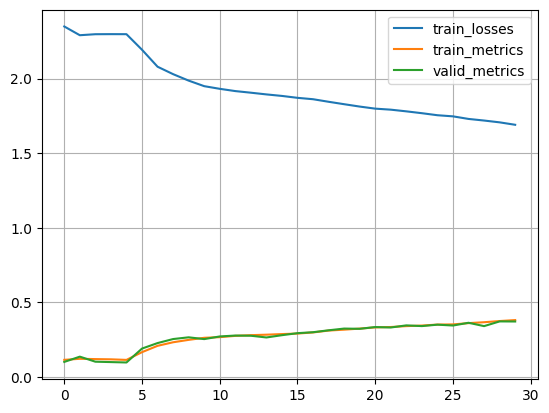

In [14]:
history_df = pd.DataFrame(data=history)
history_df.plot(grid=True)

In [15]:
history_cont = train_with_early_stopping(model, optimizer, xentropy, accuracy,
                  train_loader, valid_loader, 10, early_stopping, scheduler, device=device)

Epoch 1/10, train loss: 1.6760, train metric: 0.3888, valid metric: 0.3840
Learning rate: 0.00020
Epoch 2/10, train loss: 1.6646, train metric: 0.3944, valid metric: 0.3974
Learning rate: 0.00020
Epoch 3/10, train loss: 1.6526, train metric: 0.3955, valid metric: 0.4010
Learning rate: 0.00020
Epoch 4/10, train loss: 1.6401, train metric: 0.4048, valid metric: 0.3924
Learning rate: 0.00020
Epoch 5/10, train loss: 1.6239, train metric: 0.4100, valid metric: 0.4098
Learning rate: 0.00020
Epoch 6/10, train loss: 1.6168, train metric: 0.4114, valid metric: 0.4066
Learning rate: 0.00020
Epoch 7/10, train loss: 1.6056, train metric: 0.4149, valid metric: 0.4142
Learning rate: 0.00020
Epoch 8/10, train loss: 1.5898, train metric: 0.4207, valid metric: 0.3990
Learning rate: 0.00020
Epoch 9/10, train loss: 1.5781, train metric: 0.4274, valid metric: 0.4194
Learning rate: 0.00020
Epoch 10/10, train loss: 1.5792, train metric: 0.4265, valid metric: 0.4180
Stopping early as no improvement has been 

d. Now try adding batch-norm and compare the learning curves: is it converging faster than before? 

Does it produce a better model? How does it affect training speed?

In [16]:
class ImageClassifierBN(nn.Module):
    def __init__(self, n_inputs, n_layers, n_hidden, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden),  # Input layer
            nn.BatchNorm1d(n_hidden),
            nn.SiLU()
        )
        for i in range(n_layers):  # Hidden layers
            self.mlp.append(nn.Linear(n_hidden, n_hidden))
            self.mlp.append(nn.BatchNorm1d(n_hidden))
            self.mlp.append(nn.SiLU())
        self.mlp.append(nn.Linear(n_hidden, n_classes))  # Output layer


    def forward(self, X):
        return self.mlp(X)

In [17]:
torch.manual_seed(42)
model_bn = ImageClassifierBN(n_inputs=3 * 32 * 32, n_layers=20, n_hidden=100, n_classes=10)
model_bn.apply(use_he_init)

xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.NAdam(model_bn.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.1)
early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)

history_bn = train_with_early_stopping(model_bn, optimizer, xentropy, accuracy,
                  train_loader, valid_loader, n_epochs, early_stopping, scheduler, device=device)

Epoch 1/30, train loss: 2.0909, train metric: 0.2282, valid metric: 0.3218
Learning rate: 0.00200
Epoch 2/30, train loss: 1.7149, train metric: 0.3812, valid metric: 0.3738
Learning rate: 0.00200
Epoch 3/30, train loss: 1.5652, train metric: 0.4392, valid metric: 0.4354
Learning rate: 0.00200
Epoch 4/30, train loss: 1.4652, train metric: 0.4754, valid metric: 0.3972
Learning rate: 0.00200
Epoch 5/30, train loss: 1.3940, train metric: 0.5030, valid metric: 0.3894
Learning rate: 0.00200
Epoch 6/30, train loss: 1.3329, train metric: 0.5261, valid metric: 0.3996
Learning rate: 0.00020
Epoch 7/30, train loss: 1.1783, train metric: 0.5815, valid metric: 0.5058
Learning rate: 0.00020
Epoch 8/30, train loss: 1.1367, train metric: 0.5946, valid metric: 0.4980
Learning rate: 0.00020
Epoch 9/30, train loss: 1.1111, train metric: 0.6053, valid metric: 0.4956
Learning rate: 0.00020
Epoch 10/30, train loss: 1.0924, train metric: 0.6123, valid metric: 0.5002
Learning rate: 0.00002
Epoch 11/30, train 

e. Try replacing batch-norm with SELU, and make the necessary adjustments to ensure the network self-normalizes (i.e., standardize the input features, use LeCun normal initialization, make sure the DNN contains only a sequence of dense layers, etc.).

In [18]:
# Standardize the input features
toNormalizedTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32),
                                T.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0])])

train_and_valid_data_n = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=toNormalizedTensor
)
test_data_n = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toNormalizedTensor
)

torch.manual_seed(42)
train_data_n, valid_data_n = torch.utils.data.random_split(
    train_and_valid_data_n, [45_000, 5_000]
)

batch_size = 512
train_loader_n = DataLoader(train_data_n, batch_size=batch_size, shuffle=True)
valid_loader_n = DataLoader(valid_data_n, batch_size=batch_size)
test_loader_n = DataLoader(test_data_n, batch_size=batch_size)


In [19]:
def use_lecun_init(module: nn.Module):
    if isinstance(module, nn.Linear):
        module.weight.data = module.weight.data * 3 ** 0.5
        nn.init.zeros_(module.bias)

In [20]:
class ImageClassifierSELU(nn.Module):
    def __init__(self, n_inputs, n_layers, n_hidden, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden),  # Input layer
            nn.SELU()
        )
        for i in range(n_layers):  # Hidden layers
            self.mlp.append(nn.Linear(n_hidden, n_hidden))
            self.mlp.append(nn.SELU())
        self.mlp.append(nn.Linear(n_hidden, n_classes))  # Output layer


    def forward(self, X):
        return self.mlp(X)
    
torch.manual_seed(42)
model_selu = ImageClassifierSELU(n_inputs=3 * 32 * 32, n_layers=20, n_hidden=100, n_classes=10)
model_selu.apply(use_lecun_init)
model_selu

ImageClassifierSELU(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=100, bias=True)
    (2): SELU()
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): SELU()
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): SELU()
    (7): Linear(in_features=100, out_features=100, bias=True)
    (8): SELU()
    (9): Linear(in_features=100, out_features=100, bias=True)
    (10): SELU()
    (11): Linear(in_features=100, out_features=100, bias=True)
    (12): SELU()
    (13): Linear(in_features=100, out_features=100, bias=True)
    (14): SELU()
    (15): Linear(in_features=100, out_features=100, bias=True)
    (16): SELU()
    (17): Linear(in_features=100, out_features=100, bias=True)
    (18): SELU()
    (19): Linear(in_features=100, out_features=100, bias=True)
    (20): SELU()
    (21): Linear(in_features=100, out_features=100, bias=True)
    (22): SELU()
    (23): Linear(in_features=100, out_featur

In [21]:
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.NAdam(model_selu.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.1)
early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)

history_selu = train_with_early_stopping(model_selu, optimizer, xentropy, accuracy,
                  train_loader_n, valid_loader_n, n_epochs, early_stopping, scheduler, device=device)

Epoch 1/30, train loss: 2.6015, train metric: 0.1189, valid metric: 0.1712
Learning rate: 0.00200
Epoch 2/30, train loss: 2.1758, train metric: 0.1798, valid metric: 0.2090
Learning rate: 0.00200
Epoch 3/30, train loss: 2.1074, train metric: 0.2042, valid metric: 0.1680
Learning rate: 0.00200
Epoch 4/30, train loss: 2.0496, train metric: 0.2329, valid metric: 0.2638
Learning rate: 0.00200
Epoch 5/30, train loss: 1.9614, train metric: 0.2741, valid metric: 0.3102
Learning rate: 0.00200
Epoch 6/30, train loss: 1.9143, train metric: 0.2976, valid metric: 0.2958
Learning rate: 0.00200
Epoch 7/30, train loss: 1.9006, train metric: 0.3028, valid metric: 0.3188
Learning rate: 0.00200
Epoch 8/30, train loss: 1.8572, train metric: 0.3212, valid metric: 0.3276
Learning rate: 0.00200
Epoch 9/30, train loss: 1.8513, train metric: 0.3256, valid metric: 0.3266
Learning rate: 0.00200
Epoch 10/30, train loss: 1.8164, train metric: 0.3346, valid metric: 0.3450
Learning rate: 0.00200
Epoch 11/30, train 

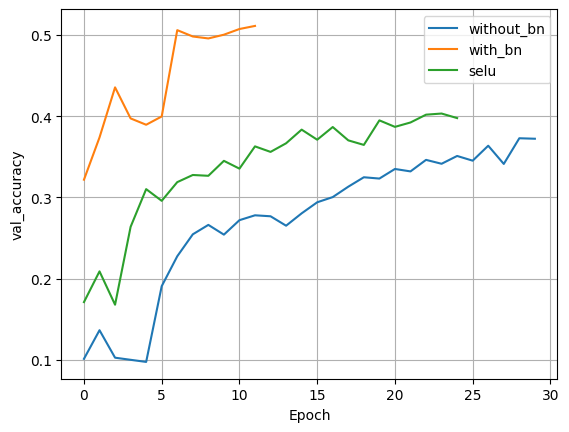

In [22]:
pd.DataFrame(
    data={
        'without_bn': pd.Series(history['valid_metrics']),
        'with_bn': pd.Series(history_bn['valid_metrics']),
        'selu': pd.Series(history_selu['valid_metrics'])
        }
).plot(grid=True, xlabel='Epoch', ylabel='val_accuracy');

f. Try regularizing the model with alpha dropout. Then, without retraining your model, see if you can achieve better accuracy using MC dropout.

In [23]:
p = 0.01
model_alpha_dropout = nn.Sequential(
    nn.Flatten(),
    nn.AlphaDropout(p),
    nn.Linear(3 * 32 * 32, 100, nn.SELU())
)
for _ in range(20):
    model_alpha_dropout.append(nn.AlphaDropout(p))
    model_alpha_dropout.append(nn.Linear(100, 100))
    model_alpha_dropout.append(nn.SELU())
model_alpha_dropout.append(nn.AlphaDropout(p))
model_alpha_dropout.append(nn.Linear(100, 10))
    

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): AlphaDropout(p=0.01, inplace=False)
  (2): Linear(in_features=3072, out_features=100, bias=True)
  (3): AlphaDropout(p=0.01, inplace=False)
  (4): Linear(in_features=100, out_features=100, bias=True)
  (5): SELU()
  (6): AlphaDropout(p=0.01, inplace=False)
  (7): Linear(in_features=100, out_features=100, bias=True)
  (8): SELU()
  (9): AlphaDropout(p=0.01, inplace=False)
  (10): Linear(in_features=100, out_features=100, bias=True)
  (11): SELU()
  (12): AlphaDropout(p=0.01, inplace=False)
  (13): Linear(in_features=100, out_features=100, bias=True)
  (14): SELU()
  (15): AlphaDropout(p=0.01, inplace=False)
  (16): Linear(in_features=100, out_features=100, bias=True)
  (17): SELU()
  (18): AlphaDropout(p=0.01, inplace=False)
  (19): Linear(in_features=100, out_features=100, bias=True)
  (20): SELU()
  (21): AlphaDropout(p=0.01, inplace=False)
  (22): Linear(in_features=100, out_features=100, bias=True)
  (23): SELU()
  (24): Alp

In [24]:
torch.manual_seed(42)
model_alpha_dropout.apply(use_lecun_init)
# patience = 10
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.NAdam(model_alpha_dropout.parameters(), lr=0.002)
# optimizer = torch.optim.SGD(model_alpha_dropout.parameters(), lr=0.01, momentum=0.9)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.1)
# early_stopping = EarlyStopping(patience=patience, delta=delta, verbose=True)

history_alpha_dropout = train_with_early_stopping(model_alpha_dropout, optimizer, xentropy, accuracy,
                  train_loader_n, valid_loader_n, n_epochs, device=device)

Epoch 1/30, train loss: 2.5322, train metric: 0.1080, valid metric: 0.0666
Epoch 2/30, train loss: 2.3005, train metric: 0.1340, valid metric: 0.1154
Epoch 3/30, train loss: 2.2264, train metric: 0.1608, valid metric: 0.1876
Epoch 4/30, train loss: 2.1005, train metric: 0.1971, valid metric: 0.1922
Epoch 5/30, train loss: 2.0931, train metric: 0.2090, valid metric: 0.2514
Epoch 6/30, train loss: 2.0164, train metric: 0.2400, valid metric: 0.2780
Epoch 7/30, train loss: 1.9886, train metric: 0.2579, valid metric: 0.3086
Epoch 8/30, train loss: 1.9632, train metric: 0.2767, valid metric: 0.3056
Epoch 9/30, train loss: 1.9317, train metric: 0.2899, valid metric: 0.3138
Epoch 10/30, train loss: 1.9026, train metric: 0.3038, valid metric: 0.3170
Epoch 11/30, train loss: 1.8514, train metric: 0.3288, valid metric: 0.3578
Epoch 12/30, train loss: 1.8355, train metric: 0.3327, valid metric: 0.3288
Epoch 13/30, train loss: 1.8089, train metric: 0.3474, valid metric: 0.3482
Epoch 14/30, train lo

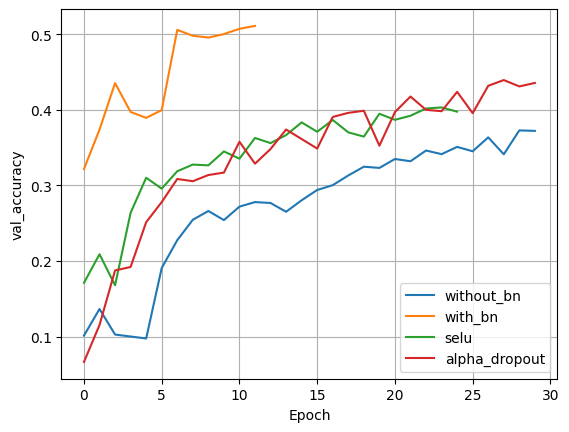

In [25]:
pd.DataFrame(
    data={
        'without_bn': pd.Series(history['valid_metrics']),
        'with_bn': pd.Series(history_bn['valid_metrics']),
        'selu': pd.Series(history_selu['valid_metrics']),
        'alpha_dropout': pd.Series(history_alpha_dropout['valid_metrics'])
        }
).plot(grid=True, xlabel='Epoch', ylabel='val_accuracy');

MC Dropout:

In [26]:
# first evaluate existing model on validation set
valid_accuracy = evaluate_tm(model_alpha_dropout, valid_loader_n, accuracy, device)
valid_accuracy

tensor(0.4356, device='mps:0')

In [27]:
# perhaps write an evaluate_tm_mc that sets the model in mc dropout mode before 
# calculating the accuracy
def evaluate_mc(model, data_loader, metric: torchmetrics.Metric, repeats=10, device=None):
    if device:
        model = model.to(device)
        metric = metric.to(device)
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.AlphaDropout):
            module.train()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
            for X_batch, y_batch in data_loader:
                if device:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    probs_sum = 0.0
                    for _ in range(repeats):
                         logits = model(X_batch)
                         probs = torch.softmax(logits, dim=1)
                         probs_sum = probs_sum + probs
                    probs_mean = probs_sum / repeats
                    preds = probs_mean.argmax(dim=1)
                metric.update(preds, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

In [28]:
evaluate_mc(model_alpha_dropout, valid_loader_n, accuracy, repeats=200, device=device)

tensor(0.4362, device='mps:0')

g. Retrain your model using 1cycle scheduling and see if it improves training speed and model accuracy.

In [50]:
from torch.optim.lr_scheduler import OneCycleLR

def train_with_onecycle(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs, early_stopping=None, scheduler: OneCycleLR | None = None, device=None):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    if device:
        model = model.to(device)
        metric = metric.to(device)
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            if device:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()    # zero the gradients FIRST
            y_pred = model(X_batch)    # forward pass
            loss = criterion(y_pred, y_batch)    # compute loss for this batch
            total_loss = total_loss +  loss.item()
            loss.backward()    # compute gradients of the loss
            optimizer.step()   # adjust the model weights based on the gradients
            metric.update(y_pred, y_batch)
            if scheduler:
                scheduler.step()  # OneCycleLr has to call .step() after every batch
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        val_metric = evaluate_tm(model, valid_loader, metric, device=device).item()
        history["valid_metrics"].append(val_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
        # Check early stopping condition
        if early_stopping:
            early_stopping.check_early_stop(val_metric)
            if early_stopping.stop_training:
                print(f"Early stopping at epoch {epoch}")
                break
        print(f"Learning rate: {scheduler.get_last_lr()[0]:.5f}")
    return history

In [37]:
def use_lecun_init_alt(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, mode="fan_in",
                                nonlinearity="linear")
        nn.init.zeros_(module.bias)

In [47]:
len(train_loader_n)

88

In [51]:
torch.manual_seed(64)
n_epochs = 60
model_selu_new = ImageClassifierSELU(n_inputs=3 * 32 * 32, n_layers=20, n_hidden=100, n_classes=10)
model_selu_new.apply(use_lecun_init_alt)
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
optimizer = torch.optim.SGD(model_selu_new.parameters(), lr=0.0001)  # NAdam didn't work well with OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, epochs=n_epochs, steps_per_epoch=len(train_loader_n))

history_one_cycle = train_with_onecycle(model_selu_new, optimizer, xentropy, accuracy,
                  train_loader_n, valid_loader_n, n_epochs, scheduler=scheduler, device=device)


Epoch 1/60, train loss: 2.1477, train metric: 0.2047, valid metric: 0.2754
Learning rate: 0.00047
Epoch 2/60, train loss: 1.9126, train metric: 0.3019, valid metric: 0.3068
Learning rate: 0.00069
Epoch 3/60, train loss: 1.8465, train metric: 0.3264, valid metric: 0.3534
Learning rate: 0.00104
Epoch 4/60, train loss: 1.8017, train metric: 0.3460, valid metric: 0.3630
Learning rate: 0.00152
Epoch 5/60, train loss: 1.7589, train metric: 0.3593, valid metric: 0.3506
Learning rate: 0.00212
Epoch 6/60, train loss: 1.7505, train metric: 0.3641, valid metric: 0.3560
Learning rate: 0.00280
Epoch 7/60, train loss: 1.7468, train metric: 0.3709, valid metric: 0.3728
Learning rate: 0.00356
Epoch 8/60, train loss: 1.6861, train metric: 0.3928, valid metric: 0.3862
Learning rate: 0.00437
Epoch 9/60, train loss: 1.6546, train metric: 0.4029, valid metric: 0.3928
Learning rate: 0.00520
Epoch 10/60, train loss: 1.6548, train metric: 0.4042, valid metric: 0.3822
Learning rate: 0.00604
Epoch 11/60, train 